# EDA – Tổng quan dữ liệu và trả lời câu hỏi

In [237]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re


PRE_MERGED = "../data/unified/preprocessed_merged.csv"

df = pd.read_csv(PRE_MERGED, encoding="utf-8-sig", encoding_errors="ignore", on_bad_lines="skip")


## 1) Tổng quan dữ liệu

In [238]:
df.columns

Index(['tieu_de', 'gia', 'dia_chi', 'dien_tich_dat', 'phong_ngu', 'phong_tam',
       'so_tang', 'phap_ly', 'ngay_dang', 'gia_tren_m2', 'diem_sinh_loi'],
      dtype='object')

### 1.1 Ý nghĩa của từng cột dữ liệu
- tieu_de: Tiêu đề bài đăng bán nhà
- gia: Giá bán (theo tỷ đồng)
- dia_chi: Địa chỉ nhà
- dien_tich_dat: Diện tích đất (theo mét vuông)
- phong_ngu: Số phòng ngủ của nhà
- phong_tam: Số phòng tắm của nhà
- so_tang: Số tầng của nhà
- phap_ly: Tình trạng pháp lý (Sổ hồng, Số đỏ, Giấy tờ không xác định)
- ngay_dang: Ngày đăng tin bán nhà
- gia_tren_m2: Giá đất trên mét vuông 
- diem_sinh_loi: Điểm số mà dòng tiền mang lại khi cho thuê

### 1.2 Kiểu dữ liệu của từng cột hiện tại

In [239]:
df.dtypes

tieu_de           object
gia              float64
dia_chi           object
dien_tich_dat    float64
phong_ngu          int64
phong_tam          int64
so_tang            int64
phap_ly           object
ngay_dang         object
gia_tren_m2      float64
diem_sinh_loi    float64
dtype: object

### 1.3 Kiểm tra và xử lí số dòng thiếu và trùng lặp

In [240]:
print("Số dòng:", len(df))
print("Số ô missing value:", df.isna().sum().sum())
print("Số dòng bị trùng lặp (tính cả dòng giống hệt nhau):", df.duplicated().sum())



Số dòng: 6974
Số ô missing value: 0
Số dòng bị trùng lặp (tính cả dòng giống hệt nhau): 5


In [241]:
df = df.drop_duplicates(inplace=False)
print("Số dòng sau khi xoá trùng lặp:", len(df))


Số dòng sau khi xoá trùng lặp: 6969


### 1.4 Phân tích dữ liệu với các dữ liệu kiểu object

In [242]:
print("Số giá trị duy nhất của tiêu đề là: ",df['tieu_de'].nunique())
print("Số giá trị duy nhất của địa chỉ là: ", df['dia_chi'].nunique())
print("Số giá trị duy nhất của pháp lý là: ", df['phap_ly'].nunique(),df['phap_ly'].unique())
print("Số giá trị duy nhất của ngày đăng là: ", df['ngay_dang'].nunique())

df['ngay_dang'] = pd.to_datetime(df['ngay_dang'], errors='coerce')
print("Ngày đăng lớn nhất",df['ngay_dang'].min().date())
print("Ngày đăng lớn nhất:", df['ngay_dang'].max().date())

df.columns




Số giá trị duy nhất của tiêu đề là:  6431
Số giá trị duy nhất của địa chỉ là:  3433
Số giá trị duy nhất của pháp lý là:  3 ['Sổ hồng' 'Sổ đỏ' 'Giấy tờ không xác định']
Số giá trị duy nhất của ngày đăng là:  250
Ngày đăng lớn nhất 2024-10-31
Ngày đăng lớn nhất: 2025-11-28


Index(['tieu_de', 'gia', 'dia_chi', 'dien_tich_dat', 'phong_ngu', 'phong_tam',
       'so_tang', 'phap_ly', 'ngay_dang', 'gia_tren_m2', 'diem_sinh_loi'],
      dtype='object')

### 1.5 Phân tích và xử lí dữ liệu với các dữ liệu dạng numeric


In [243]:
df.describe()

,gia,dien_tich_dat,phong_ngu,phong_tam,so_tang,ngay_dang,gia_tren_m2,diem_sinh_loi
count,6969.000000,6969.000000,6969.000000,6969.000000,6969.000000,6969,6969.000000,6969.000000
mean,25.774968,75.194897,4.800402,4.736978,6.015067,2025-10-12 01:24:18.286698240,0.450439,16.743609
min,0.014000,1.500000,1.000000,1.000000,1.000000,2024-10-31 00:00:00,0.000000,3.500000
25%,6.400000,38.400000,3.000000,3.000000,3.000000,2025-10-16 00:00:00,0.130000,11.000000
50%,9.300000,54.200000,4.000000,4.000000,4.000000,2025-11-18 00:00:00,0.200000,13.000000
75%,17.600000,80.000000,5.000000,5.000000,5.000000,2025-11-25 00:00:00,0.280000,17.800000
max,9400.000000,6117.000000,100.000000,101.000000,9810.000000,2025-11-28 00:00:00,228.330000,9828.000000
std,246.665084,125.004374,4.869499,4.843872,117.520627,NaN,6.183518,117.917222


In [244]:
# Xử lí outlier dựa theo cảm quan và quan sát thủ công dữ liệu
df = df[(df['gia'] <=500) & (df['so_tang'] <= 16) & (df['phong_ngu'] <= 30) & (df['phong_tam'] <= 30) & (df['dien_tich_dat'] <= 3000)]

df.describe()

,gia,dien_tich_dat,phong_ngu,phong_tam,so_tang,ngay_dang,gia_tren_m2,diem_sinh_loi
count,6872.000000,6872.000000,6872.000000,6872.000000,6872.000000,6872,6872.000000,6872.000000
mean,16.593046,71.938161,4.510477,4.447905,4.427823,2025-10-12 02:10:45.401629696,0.224753,14.780907
min,0.014000,5.000000,1.000000,1.000000,1.000000,2024-10-31 00:00:00,0.000000,3.500000
25%,6.350000,38.000000,3.000000,3.000000,3.000000,2025-10-16 00:00:00,0.130000,11.000000
50%,9.200000,54.000000,4.000000,4.000000,4.000000,2025-11-17 00:00:00,0.200000,13.000000
75%,17.000000,80.000000,5.000000,5.000000,5.000000,2025-11-25 00:00:00,0.270000,17.000000
max,450.000000,2515.000000,30.000000,30.000000,16.000000,2025-11-28 00:00:00,9.000000,69.000000
std,25.514678,81.235701,2.978828,2.992188,2.036924,NaN,0.178864,7.008733


### 1.6 Tương quan giữa các cột numberic

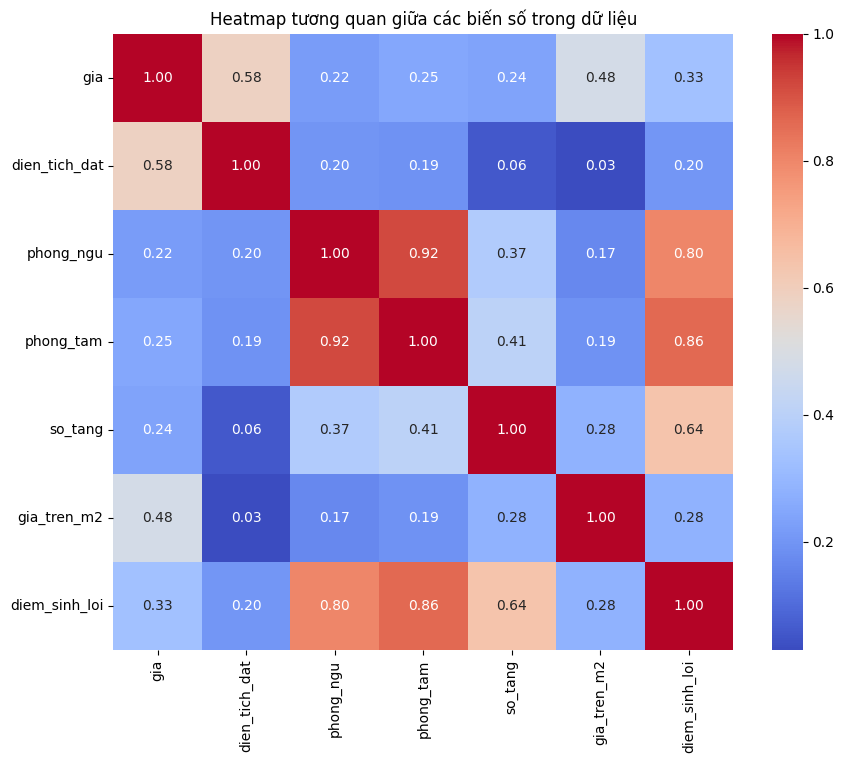

In [245]:


# Tính ma trận tương quan
corr_matrix = df.corr(numeric_only=True)

# Vẽ heatmap cho ma trận tương quan
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap tương quan giữa các biến số trong dữ liệu")
plt.show()


Nhận xét: Giá có sự tương quan mạnh nhất với diện tích đất và diem_sinh_loi có tương quan mạnh nhất với phong_ngu,phong_tam, so_tang bởi vì diem_sinh_loi chủ yếu được tính dựa trên các thuộc tính này để xem có phù hợp để cho thuê hay không

## 2) EDA để trả lời câu hỏi

### 2.1 Câu hỏi 1
-   Câu hỏi: Tỷ lệ các loại pháp lý (sổ đỏ/sổ hồng, giấy tờ không xác định) theo quận/thành phố?

In [246]:


# =========================
# 1. HÀM TÁCH QUẬN / HUYỆN
# =========================
def extract_quan(addr):
    if pd.isna(addr):
        return np.nan
    s = str(addr)

    # Quận: "Quận 1", "Quận Bình Thạnh", "Quận 2 (TP. Thủ Đức)", "Q.1", "Q.Bình Thạnh"
    m = re.search(r'(Quận|Q\.)\s*([^,]+)', s, flags=re.IGNORECASE)
    if m:
        return 'Quận ' + m.group(2).strip()

    # Huyện: "Huyện Bình Chánh", "H. Bình Chánh"
    m = re.search(r'(Huyện|H\.)\s*([^,]+)', s, flags=re.IGNORECASE)
    if m:
        return 'Huyện ' + m.group(2).strip()

    return np.nan

df['quan'] = df['dia_chi'].apply(extract_quan)

# =========================
# 2. HÀM TÁCH THÀNH PHỐ
#    - CHỈ BẮT Ở CUỐI CHUỖI
# =========================
def extract_thanh_pho(addr):
    if pd.isna(addr):
        return np.nan
    s = str(addr)

    last = s.split(',')[-1].strip().lower()

    # Các biến thể của TP.HCM
    hcm_patterns = [
        'hồ chí minh',
        'thành phố hồ chí minh',
        'tp.hcm',
        'tp hcm',
        'tphcm',
        'hcm'
    ]
    hanoi_patterns = [
        'hà nội',
        'hn'
    ]

    if any(p in last for p in hcm_patterns):
        return 'Hồ Chí Minh'
    if any(p in last for p in hanoi_patterns):
        return 'Hà Nội'

    return np.nan  # không tìm thấy rõ ràng

df['thanh_pho'] = df['dia_chi'].apply(extract_thanh_pho)
# ======================================
# 3. SUY LUẬN THÀNH PHỐ TỪ TÊN QUẬN (NẾU CẦN)
#    - Xử lý case như "Xa Lộ Hà Nội, ..., Quận 2 (TP. Thủ Đức)"
#      (không có "Hồ Chí Minh" ở cuối)
# ======================================

# Danh sách từ khoá quận/huyện thuộc TP.HCM
hcm_quan_keywords = [
    'Quận 1', 'Quận 2', 'Quận 3', 'Quận 4', 'Quận 5', 'Quận 6',
    'Quận 7', 'Quận 8', 'Quận 9', 'Quận 10', 'Quận 11', 'Quận 12',
    'Bình Thạnh', 'Gò Vấp', 'Phú Nhuận', 'Bình Tân', 'Tân Bình',
    'Tân Phú', 'Thủ Đức', 'TP. Thủ Đức', 'Bình Chánh', 'Hóc Môn',
    'Củ Chi', 'Nhà Bè', 'Cần Giờ'
]

# Danh sách từ khoá quận/huyện thuộc Hà Nội (cơ bản)
hn_quan_keywords = [
    'Ba Đình', 'Hoàn Kiếm', 'Tây Hồ', 'Long Biên', 'Cầu Giấy',
    'Đống Đa', 'Hai Bà Trưng', 'Hoàng Mai', 'Thanh Xuân', 'Hà Đông',
    'Bắc Từ Liêm', 'Nam Từ Liêm'
]

# Gán TP.HCM nếu thành_pho đang NaN nhưng quận thuộc 1 trong quận TP.HCM
mask_hcm = (
    df['thanh_pho'].isna()
    & df['quan'].apply(
        lambda x, ks=hcm_quan_keywords: isinstance(x, str) and any(k in x for k in ks)
    )
)
df.loc[mask_hcm, 'thanh_pho'] = 'Hồ Chí Minh'

# Gán Hà Nội nếu thanh_pho NaN nhưng quận thuộc 1 trong quận Hà Nội
mask_hn = (
    df['thanh_pho'].isna()
    & df['quan'].apply(
        lambda x, ks=hn_quan_keywords: isinstance(x, str) and any(k in x for k in ks)
    )
)


df.loc[mask_hn, 'thanh_pho'] = 'Hà Nội'

df = df.dropna()
mask_quan_h = (df['thanh_pho'] == 'Hà Nội') & (df['quan'].str.strip() == 'Quận H')
df = df[~mask_quan_h]

# =========================
# 4. TÍNH TỶ LỆ PHÁP LÝ
# =========================

# Tỷ lệ theo THÀNH PHỐ
ty_le_theo_thanh_pho = (
    pd.crosstab(df['thanh_pho'], df['phap_ly'], normalize='index') * 100
).round(2)

print("Tỷ lệ pháp lý theo THÀNH PHỐ (%):")
print(ty_le_theo_thanh_pho)

# Tỷ lệ theo QUẬN trong từng THÀNH PHỐ
ty_le_theo_quan = (
    pd.crosstab([df['thanh_pho'], df['quan']], df['phap_ly'], normalize='index') * 100
).round(2)

print("\nTỷ lệ pháp lý theo QUẬN trong từng THÀNH PHỐ (%):")
print(ty_le_theo_quan)



Tỷ lệ pháp lý theo THÀNH PHỐ (%):
phap_ly      Giấy tờ không xác định  Sổ hồng  Sổ đỏ
thanh_pho                                          
Hà Nội                        40.72    37.06  22.22
Hồ Chí Minh                   10.03    89.80   0.17

Tỷ lệ pháp lý theo QUẬN trong từng THÀNH PHỐ (%):
phap_ly                                 Giấy tờ không xác định  Sổ hồng  Sổ đỏ
thanh_pho   quan                                                              
Hà Nội      Quận Ba Đình                                 56.02     3.38  40.60
            Quận Bắc Từ Liêm                             12.77    87.23   0.00
            Quận Bắc Từ Liêm Hà Nội                       0.00   100.00   0.00
            Quận Cầu Giấy                                62.80     8.29  28.91
            Quận Hai Bà Trưng                            44.77    12.09  43.14
            Quận Hoàn Kiếm                               19.30    10.53  70.18
            Quận Hoàng Mai                               11.72    88.28   0

### Visualize kết quả


### Tỷ lệ pháp lý theo thành phố

<Figure size 800x500 with 0 Axes>

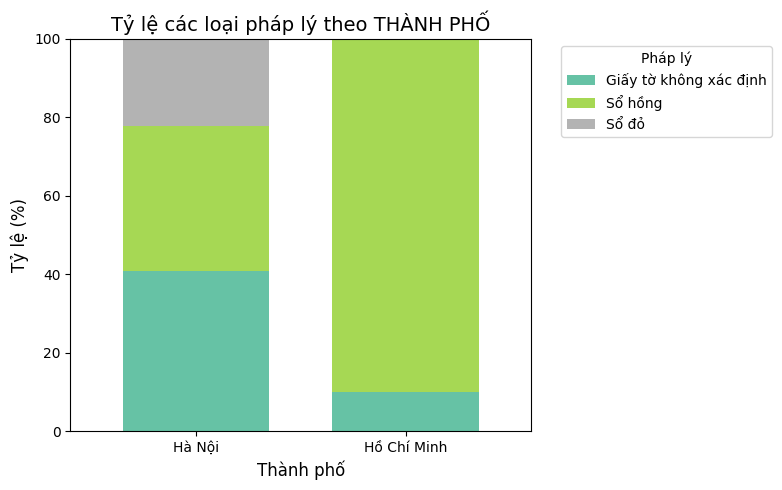

In [247]:

plt.figure(figsize=(8, 5));

ax = ty_le_theo_thanh_pho.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 5),
    colormap='Set2',   # hoặc 'tab20', 'Pastel1', ...
    width=0.7
);

ax.set_title('Tỷ lệ các loại pháp lý theo THÀNH PHỐ', fontsize=14);
ax.set_xlabel('Thành phố', fontsize=12)
ax.set_ylabel('Tỷ lệ (%)', fontsize=12)
ax.set_ylim(0, 100);

plt.xticks(rotation=0)           # tên TP nằm ngang
plt.legend(title='Pháp lý', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show();

Nhận xét: Khoảng 90% tin đăng ở TP. Hồ Chí Minh có Sổ Hồng và chỉ 10% là Giấy tờ không xác định, gần như là không có Sổ đỏ cho thấy Các tin ở HCM tính chuẩn hóa pháp lý khá cao, gần như “mặc định” là Sổ hồng,tỷ lệ tin pháp lý mơ hồ thấp. Còn ở Hà Nội khoảng 40% là giấy tờ không xác định(tỷ lệ rất lớn),và vẫn còn khá lớn tỷ lệ đáng kể bất động sản mang Sổ đỏ

### Tỷ lệ pháp lý theo quận Hà Nội

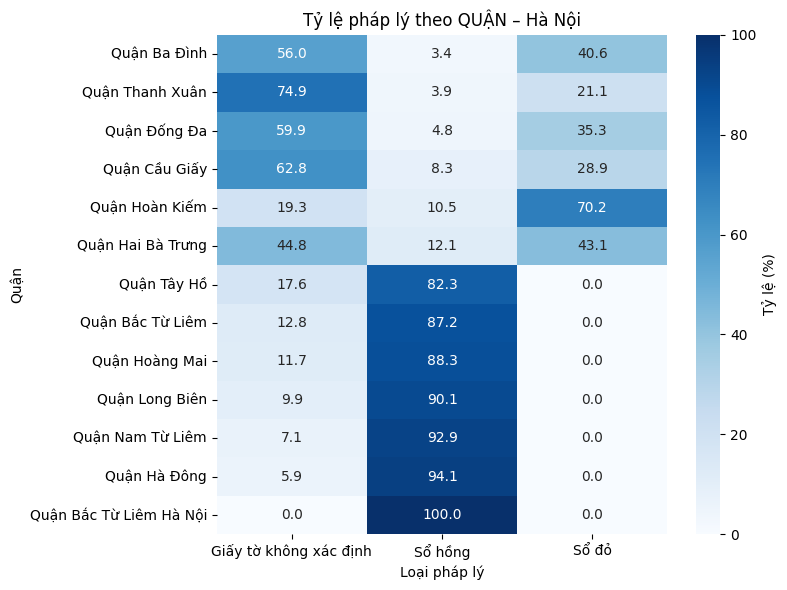

In [248]:


# --- Hà Nội ---
ty_hn = ty_le_theo_quan.xs('Hà Nội')   # lấy phần index 'Hà Nội'
ty_hn = ty_hn.sort_values('Sổ hồng')   # tuỳ chọn: sắp xếp theo % sổ hồng

plt.figure(figsize=(8, 6))
sns.heatmap(
    ty_hn,
    annot=True, fmt='.1f', cmap='Blues',
    cbar_kws={'label': 'Tỷ lệ (%)'}
)
plt.title('Tỷ lệ pháp lý theo QUẬN – Hà Nội')
plt.xlabel('Loại pháp lý')
plt.ylabel('Quận')
plt.tight_layout()
plt.show()


Nhận xét: Các quận trung tâm như Hoàn Kiếm, Ba Đình, Đống Đa, Hai Bà Trưng, Thanh Xuân, Cầu Giấy có nhiều Sổ đỏ nhưng cũng rất nhiều tin không ghi rõ pháp lý. Các quận còn lại có tỷ lệ Sổ hồng áp đảo, thể hiện sự chuẩn hóa hơn.

### Tỷ lệ pháp lý theo quận Hồ Chí Minh

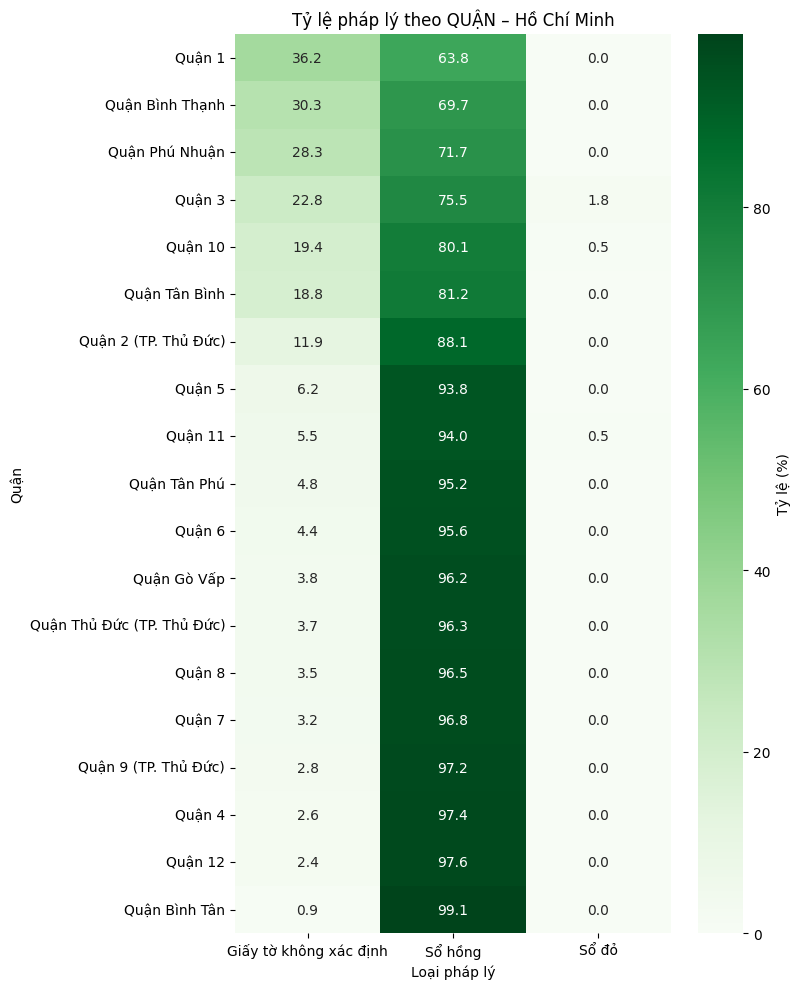

In [249]:
# --- Hồ Chí Minh ---
ty_hcm = ty_le_theo_quan.xs('Hồ Chí Minh')
ty_hcm = ty_hcm.sort_values('Sổ hồng')

plt.figure(figsize=(8, 10))
sns.heatmap(
    ty_hcm,
    annot=True, fmt='.1f', cmap='Greens',
    cbar_kws={'label': 'Tỷ lệ (%)'}
)
plt.title('Tỷ lệ pháp lý theo QUẬN – Hồ Chí Minh')
plt.xlabel('Loại pháp lý')
plt.ylabel('Quận')
plt.tight_layout()
plt.show()

Nhận xét: Ở TPHCM đa số toàn số hồng, rất ít sổ đỏ khác biệt chủ yếu nằm ở tỷ lệ tin “Giấy tờ không xác định”, cao nhất ở các quận như (Q1, Bình Thạnh, Phú Nhuận, Q3, Q10, Tân Bình).


### Kết luận
So sánh theo thành phố
- Nếu chỉ nhìn tổng thể, mua nhà ở HCM có xác suất cao gặp tài sản mang Sổ hồng, ít “giấy tờ lạ”.
- Ở Hà Nội, người mua/nhà đầu tư cần đọc kỹ phần mô tả pháp lý, vì tỷ lệ tin không ghi rõ hoặc không chuẩn hoá khá lớn; đồng thời vẫn tồn tại hai tỉ lệ là Sổ đỏ – Sổ hồng.
So sánh theo quận ở Hà Nội
- Đối với các quận Hoàn Kiếm, Ba Đình, Đống Đa, Hai Bà Trưng, Thanh Xuân, Cầu Giấy có nhiều Sổ đỏ nhưng cũng rất nhiều tin không ghi rõ pháp lý dẫn đến đây có thể là các quận có rủi ro cao,cần thẩm định kỹ từng tài sản.
- Đối với các quận còn lại thì ít rủi ro về “loại sổ”, phù hợp với người mua ưu tiên tính rõ ràng.

So sánh theo quận ở TP.Hồ Chí Minh
- HCM nhìn chung an toàn về loại giấy tờ (gần như toàn Sổ hồng).
- Nếu cần cẩn trọng hơn, đó là những quận trung tâm như Q1, Q3, Bình Thạnh, Phú Nhuận, Q10, Tân Bình, nơi tỷ lệ tin “không rõ pháp lý” cao hơn đáng kể.

Ứng dụng thực tế cho người mua/nhà đầu tư là có thể dùng bản đồ tỷ lệ pháp lý để chọn khu vực phù hợp rủi ro:
- Ưa an toàn, rõ ràng thì ưu tiên các quận “toàn Sổ hồng” thường là các khu vực ven thành phố
- Chấp nhận pháp lý đa dạng để săn tài sản đặc biệt (nhà phố cũ, vị trí hiếm…) nhưng cũng cần hiểu rõ và làm rõ về các loại giấy tờ nếu mua nhà thường là các quận trung tâm Hà Nội/HCM.



### 2.2 Câu hỏi 2


### 2.3 Câu hỏi 3

### 2.4 Câu hỏi 4

### 2.5 Câu hỏi 5